# Module 13 — Time Series Analysis & Forecasting

**Statistics Deep Dive · Notebook 13 of 13**

Every method so far assumed **independent** observations. Data collected over time break that assumption by their very nature: today's value resembles yesterday's, this December resembles last December. Ignoring this dependence produces wildly over-confident — sometimes completely spurious — results. Exploiting it is what makes **forecasting** possible.

### 🎯 Learning goals
After this module you can …
1. describe a series in terms of **trend, seasonality and noise**, and measure **autocorrelation**,
2. smooth a series with **moving averages** and **exponential smoothing**,
3. **decompose** a series (additive, multiplicative, STL) and seasonally adjust it,
4. explain **stationarity**, test for unit roots, and recognise **spurious regression**,
5. read **ACF/PACF** plots and fit **(S)ARIMA** models with honest prediction intervals,
6. evaluate forecasts properly: **benchmarks, error measures, rolling-origin cross-validation**.

### 🗺️ Contents
1. Anatomy of a time series · 2. Autocorrelation · 3. Smoothing · 4. Decomposition · 5. Stationarity & spurious regression · 6. ACF & PACF signatures · 7. (S)ARIMA models · 8. Evaluating forecasts · 9. Exercises · 10. Takeaways

In [1]:
# --- Course setup (identical in every module) ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 90, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C = sns.color_palette("deep")      # C[0] blue, C[1] orange, C[2] green, C[3] red, C[4] purple
rng = np.random.default_rng(42)    # seeded generator => reproducible results

# --- additional tools for this module ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

---
## 1. Anatomy of a time series

A time series is a sequence of observations $y_1,y_2,\dots,y_T$ **ordered in time**, usually at equal intervals. The classical mental model splits it into components:

$$\text{additive: } y_t=T_t+S_t+R_t\qquad\qquad\text{multiplicative: } y_t=T_t\times S_t\times R_t$$

* **Trend** $T_t$ — the slow, long-run movement of the level.
* **Seasonality** $S_t$ — a pattern that repeats with a **fixed, known period** (day of week, month of year).
* **Remainder** $R_t$ — what is left: irregular noise, often still autocorrelated.

(A *cycle* — e.g. the business cycle — also rises and falls, but without a fixed period; it is usually absorbed into the trend.) Use the multiplicative form when the seasonal swings **grow with the level**; taking logs turns it into the additive form.

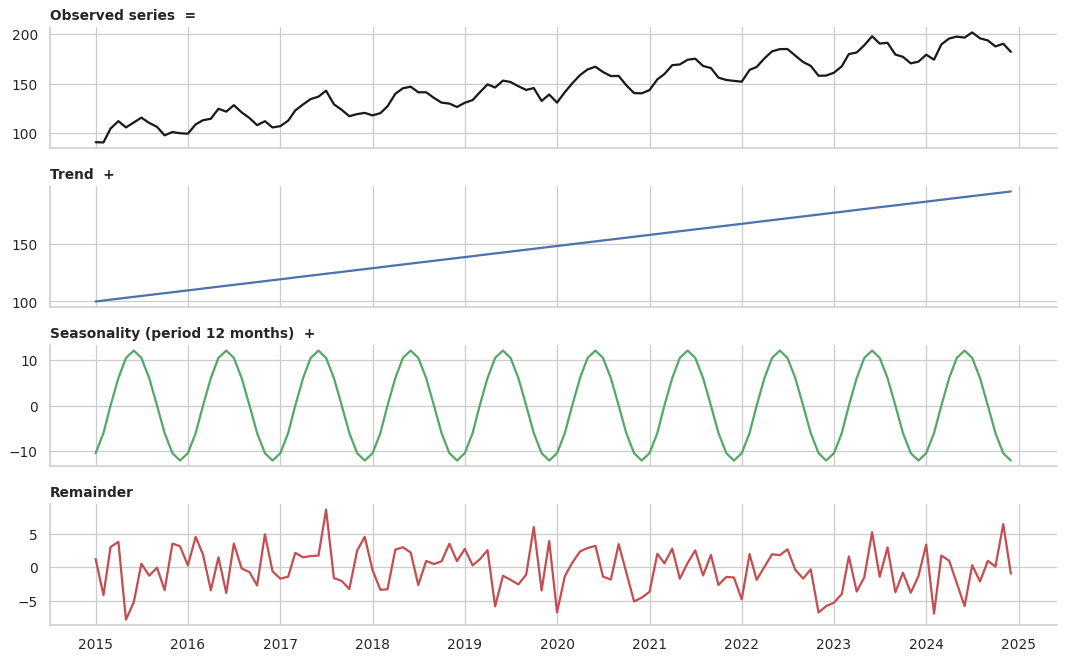

In [2]:
t = np.arange(120); idx = pd.date_range("2015-01-01", periods=120, freq="MS")
trend = 100 + .8 * t; seasonal = 12 * np.sin(2 * np.pi * (t % 12 - 2) / 12); noise = rng.normal(0, 4, 120)
fig, axes = plt.subplots(4, 1, figsize=(12, 7.5), sharex=True)
for ax, comp, name, col in zip(axes, [trend + seasonal + noise, trend, seasonal, noise], ["Observed series  =", "Trend  +", "Seasonality (period 12 months)  +", "Remainder"], ["k", C[0], C[2], C[3]]):
    ax.plot(idx, comp, color=col, lw=1.8); ax.set_title(name, loc="left", fontsize=11)
plt.tight_layout(); plt.show()

---
## 2. Autocorrelation — the series' memory

The **autocorrelation at lag $k$** is the correlation of the series with a copy of itself shifted by $k$ time steps:

$$r_k=\frac{\sum_{t=k+1}^{T}(y_t-\bar y)(y_{t-k}-\bar y)}{\sum_{t=1}^{T}(y_t-\bar y)^2}$$

The plot of $r_k$ against $k$ is the **autocorrelation function (ACF)** or *correlogram*. For pure noise, about 95 % of the $r_k$ lie within $\pm1.96/\sqrt T$ (the shaded band). Below: the detrended series from section 1.

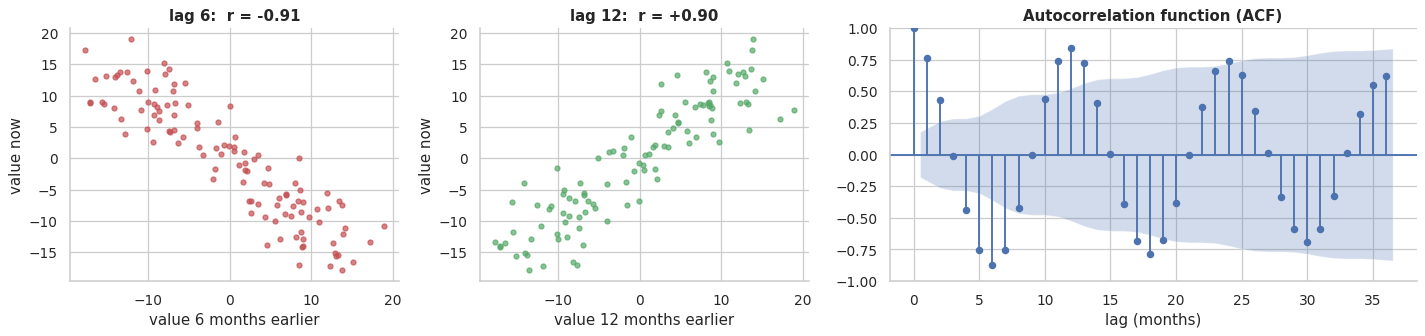

In [3]:
y = pd.Series(seasonal + noise, index=idx)
fig, axes = plt.subplots(1, 3, figsize=(16, 3.9), gridspec_kw={"width_ratios": [1, 1, 1.6]})
for ax, k, col in zip(axes[:2], [6, 12], [C[3], C[2]]):
    ax.scatter(y.shift(k), y, s=16, color=col, alpha=.7); ax.set(xlabel=f"value {k} months earlier", ylabel="value now", title=f"lag {k}:  r = {y.autocorr(k):+.2f}")
plot_acf(y, lags=36, ax=axes[2], color=C[0]); axes[2].set(title="Autocorrelation function (ACF)", xlabel="lag (months)")
plt.tight_layout(); plt.show()

**Reading the figure.** Six months apart the series is in the *opposite* season → strong negative correlation; twelve months apart it is in the *same* season → strong positive correlation. The ACF shows this as a wave with period 12 — the fingerprint of seasonality. A trend, by contrast, shows up as an ACF that decays very slowly from values near 1.

**Why it matters for everything you learned before:** with positive autocorrelation, $n$ observations contain far less information than $n$ independent ones. Standard errors from the usual formulas are too small, confidence intervals too narrow, and p-values far too optimistic.

---
## 3. Smoothing — seeing the signal through the noise

* **Moving average (MA) of window $m$:** the mean of the $m$ observations around $t$. A window equal to the seasonal period (7 days, 12 months) averages the seasonality away **exactly** and leaves the trend. *Centred* windows are for describing the past; *trailing* windows for real-time monitoring (they lag behind).
* **Exponentially weighted moving average (EWMA):** $\;\ell_t=\alpha\,y_t+(1-\alpha)\,\ell_{t-1}$ — a weighted average of all past values with geometrically decaying weights. Small $\alpha$ → smooth but sluggish; large $\alpha$ → reactive but noisy. It is also the simplest forecasting method ("simple exponential smoothing").

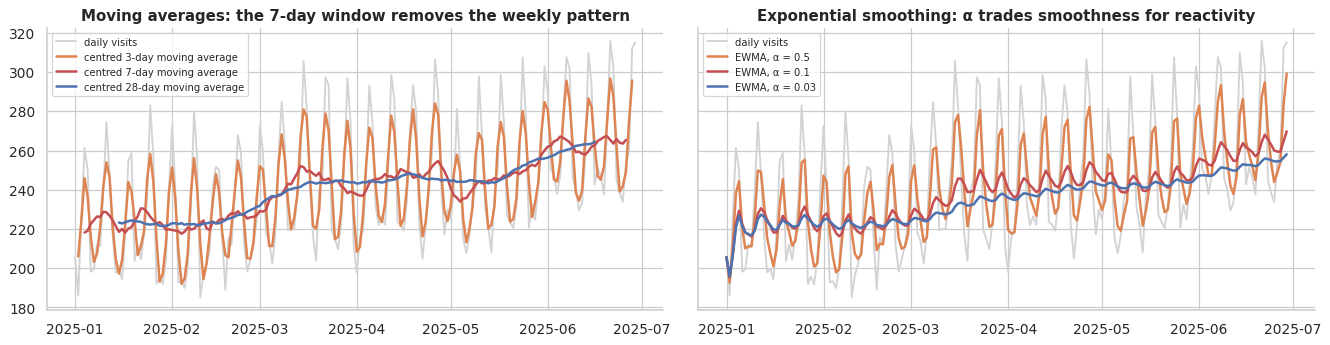

In [4]:
days = pd.date_range("2025-01-01", periods=180, freq="D")
level = 200 + np.cumsum(rng.normal(.3, 2.5, 180)); weekly = np.array([1, .96, .97, 1.0, 1.1, 1.3, 1.22])[days.dayofweek]
visits = pd.Series(level * weekly + rng.normal(0, 8, 180), index=days)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 4), sharey=True)
a1.plot(visits, color="lightgrey", label="daily visits")
for w, col in [(3, C[1]), (7, C[3]), (28, C[0])]: a1.plot(visits.rolling(w, center=True).mean(), color=col, lw=2, label=f"centred {w}-day moving average")
a1.set_title("Moving averages: the 7-day window removes the weekly pattern"); a1.legend(fontsize=8)
a2.plot(visits, color="lightgrey", label="daily visits")
for alpha, col in [(.5, C[1]), (.1, C[3]), (.03, C[0])]: a2.plot(visits.ewm(alpha=alpha).mean(), color=col, lw=2, label=f"EWMA, α = {alpha}")
a2.set_title("Exponential smoothing: α trades smoothness for reactivity"); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## 4. Decomposition — estimating trend and seasonality

**Classical decomposition:** estimate the trend with a centred moving average, remove it, average the detrended values per season, and call the rest remainder. **STL** (*Seasonal-Trend decomposition using Loess*) is the modern, robust version: the seasonal pattern may evolve slowly, and outliers do not distort it.

**Real data:** monthly atmospheric CO₂ at Mauna Loa, Hawaii (ppm) — the famous *Keeling curve* (bundled with statsmodels).

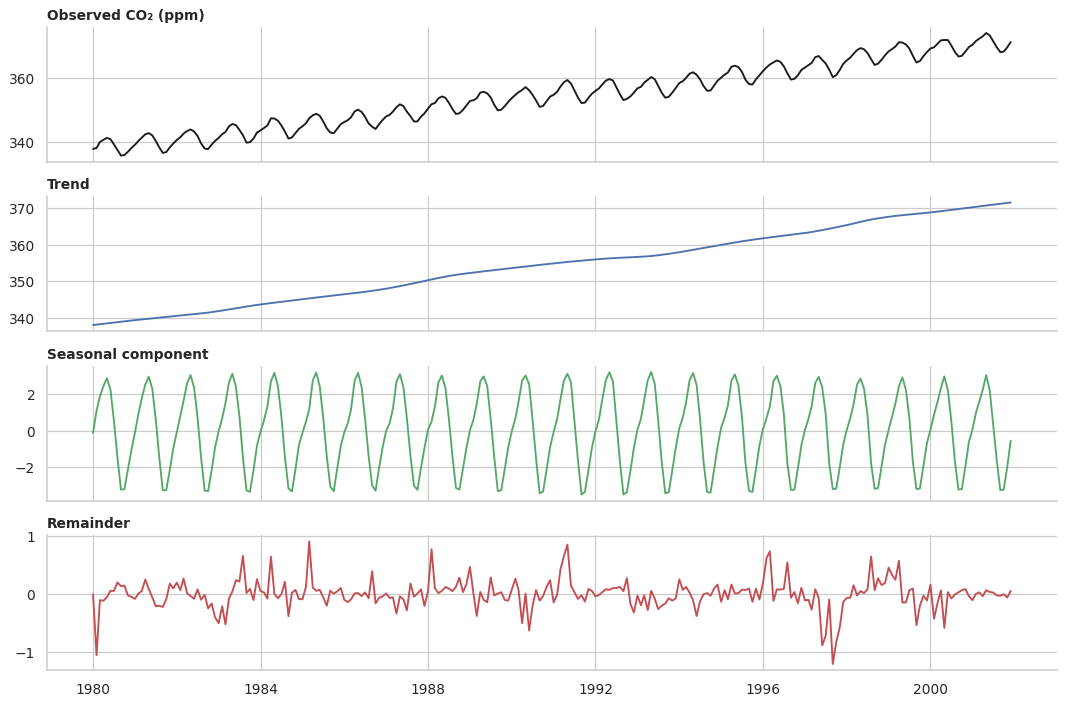

trend: +1.52 ppm per year;  seasonal peak in month 5 (+3.1 ppm), trough in month 10 (-3.3 ppm)


In [5]:
co2 = sm.datasets.co2.load_pandas().data["co2"].resample("MS").mean().interpolate().loc["1980":]
stl = STL(co2, period=12, robust=True).fit()
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
for ax, comp, name, col in zip(axes, [co2, stl.trend, stl.seasonal, stl.resid], ["Observed CO₂ (ppm)", "Trend", "Seasonal component", "Remainder"], ["k", C[0], C[2], C[3]]):
    ax.plot(comp, color=col, lw=1.5); ax.set_title(name, loc="left", fontsize=11)
plt.tight_layout(); plt.show()
monthly = stl.seasonal.groupby(stl.seasonal.index.month).mean()
print(f"trend: +{(stl.trend.iloc[-1] - stl.trend.iloc[0]) / (len(co2) / 12):.2f} ppm per year;  seasonal peak in month {monthly.idxmax()} ({monthly.max():+.1f} ppm), trough in month {monthly.idxmin()} ({monthly.min():+.1f} ppm)")

**Reading the figure.** The trend rises by about 1.5 ppm per year. The seasonal component is the biosphere "breathing": northern-hemisphere plants absorb CO₂ in summer (trough in early autumn) and release it in winter (peak in May). The remainder is tiny compared with both. Subtracting the seasonal component gives the **seasonally adjusted** series — the form in which unemployment or GDP figures are usually reported.

---
## 5. Stationarity, random walks and spurious regression

A series is **(weakly) stationary** if its mean, variance and autocorrelation structure do not change over time. Most time-series models — and all the classical statistics of this course — need stationarity. Three archetypes:

| Process | Definition | Behaviour |
|---|---|---|
| **White noise** | $y_t=\varepsilon_t$ | no memory; stationary |
| **AR(1)**, $\lvert\phi\rvert<1$ | $y_t=\phi\,y_{t-1}+\varepsilon_t$ | short memory; shocks die out; **mean-reverting**; stationary |
| **Random walk** | $y_t=y_{t-1}+\varepsilon_t$ | infinite memory; shocks are permanent; variance grows with $t$; **not stationary** ("unit root") |

**Differencing** $\nabla y_t=y_t-y_{t-1}$ turns a random walk into white noise (stock *prices* → *returns*). Seasonal differencing $y_t-y_{t-12}$ removes stable seasonality. The **augmented Dickey–Fuller (ADF) test** has $H_0$: *unit root (non-stationary)* — a small p-value is evidence **for** stationarity.

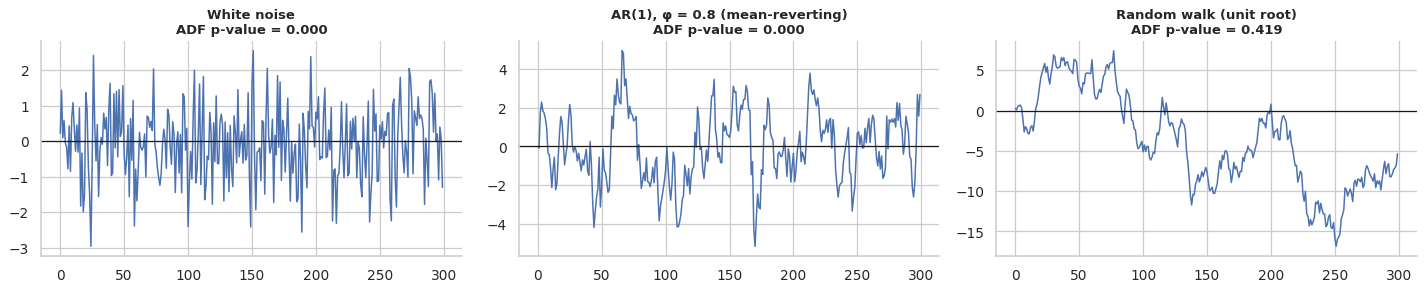

In [6]:
e = rng.normal(0, 1, (3, 300)); wn = e[0]; ar = np.zeros(300); rw = np.cumsum(e[2])
for i in range(1, 300): ar[i] = .8 * ar[i - 1] + e[1, i]
fig, axes = plt.subplots(1, 3, figsize=(16, 3.4))
for ax, s, name in zip(axes, [wn, ar, rw], ["White noise", "AR(1), φ = 0.8 (mean-reverting)", "Random walk (unit root)"]):
    ax.plot(s, color=C[0], lw=1.2); ax.axhline(0, color="k", lw=1); ax.set_title(f"{name}\nADF p-value = {adfuller(s)[1]:.3f}", fontsize=10.5)
plt.tight_layout(); plt.show()

### 5.1 Spurious regression — the most dangerous trap in time-series analysis

Regress one random walk on another, **completely independent** one. Both wander, both have "trends" by chance — and ordinary regression, which assumes independent errors, finds a "highly significant" relationship most of the time. We simulate 2,000 such pairs (length 200) and compare with the same analysis on the **differenced** series.

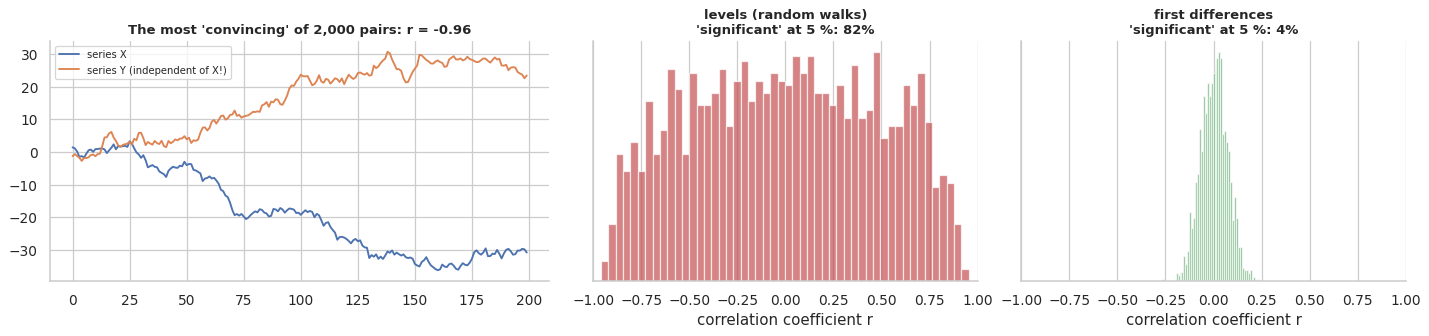

In [7]:
R, T = 2000, 200
walks_x, walks_y = np.cumsum(rng.normal(0, 1, (R, T)), axis=1), np.cumsum(rng.normal(0, 1, (R, T)), axis=1)
def corr_and_p(x, y):
    xc, yc = x - x.mean(axis=1, keepdims=True), y - y.mean(axis=1, keepdims=True)
    r = (xc * yc).sum(axis=1) / np.sqrt((xc ** 2).sum(axis=1) * (yc ** 2).sum(axis=1)); n = x.shape[1]
    return r, 2 * stats.t.sf(np.abs(r) * np.sqrt((n - 2) / (1 - r ** 2)), n - 2)
r_lvl, p_lvl = corr_and_p(walks_x, walks_y); r_dif, p_dif = corr_and_p(np.diff(walks_x), np.diff(walks_y))

fig, axes = plt.subplots(1, 3, figsize=(16, 3.9), gridspec_kw={"width_ratios": [1.3, 1, 1]})
i = np.abs(r_lvl).argmax(); axes[0].plot(walks_x[i], color=C[0], label="series X"); axes[0].plot(walks_y[i], color=C[1], label="series Y (independent of X!)")
axes[0].set_title(f"The most 'convincing' of 2,000 pairs: r = {r_lvl[i]:+.2f}", fontsize=10.5); axes[0].legend(fontsize=8)
for ax, r, p, name in [(axes[1], r_lvl, p_lvl, "levels (random walks)"), (axes[2], r_dif, p_dif, "first differences")]:
    ax.hist(r, bins=50, color=C[3] if "levels" in name else C[2], alpha=.7); ax.set(xlim=(-1, 1), xlabel="correlation coefficient r", yticks=[])
    ax.set_title(f"{name}\n'significant' at 5 %: {(p < .05).mean():.0%}", fontsize=10.5)
plt.tight_layout(); plt.show()

**Reading the figure.** Between independent random walks, correlations of ±0.8 are commonplace and about **five out of six** regressions are "significant" — a false-positive rate of over 80 % instead of 5 %. After differencing, everything is as it should be. This is the mechanism behind countless "X predicts Y" charts of two trending series.

**Rules:** (1) never regress one trending series on another without checking the **residuals** for autocorrelation (Durbin–Watson statistic far below 2 is the alarm signal); (2) analyse **changes** (differences, growth rates, returns) instead of levels, or use proper tools for non-stationary series (cointegration analysis).

---
## 6. ACF & PACF — fingerprints of AR and MA processes

Two building blocks describe short-term dependence in a stationary series:

* **AR($p$)** — *autoregressive*: $y_t=\phi_1y_{t-1}+\dots+\phi_py_{t-p}+\varepsilon_t$ (regression on its own past),
* **MA($q$)** — *moving average*: $y_t=\varepsilon_t+\theta_1\varepsilon_{t-1}+\dots+\theta_q\varepsilon_{t-q}$ (memory of the last $q$ shocks).

The **partial autocorrelation function (PACF)** gives the correlation between $y_t$ and $y_{t-k}$ *after removing* the influence of the lags in between (compare partial correlation, Module 9).

| Process | ACF | PACF |
|---|---|---|
| AR($p$) | decays gradually | **cuts off after lag $p$** |
| MA($q$) | **cuts off after lag $q$** | decays gradually |
| ARMA | decays | decays |

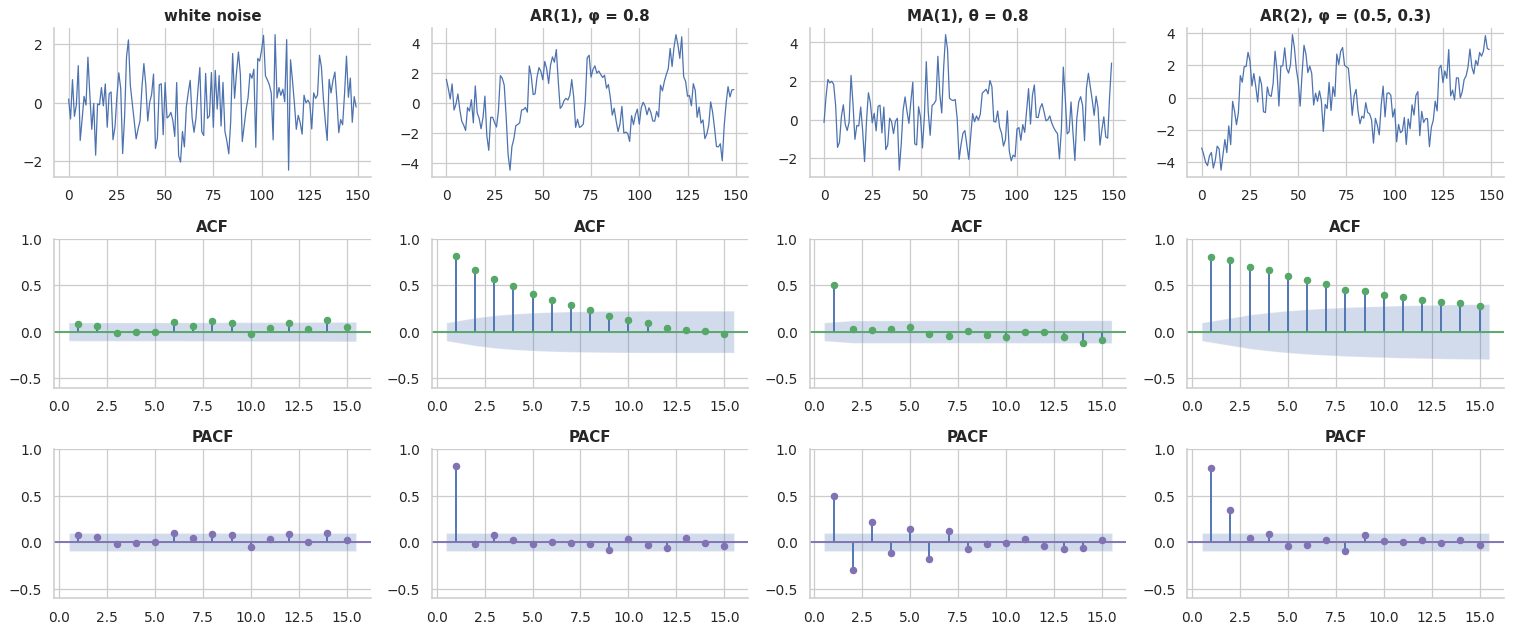

In [8]:
sims = {"white noise": ([1], [1]), "AR(1), φ = 0.8": ([1, -.8], [1]), "MA(1), θ = 0.8": ([1], [1, .8]), "AR(2), φ = (0.5, 0.3)": ([1, -.5, -.3], [1])}
fig, axes = plt.subplots(3, 4, figsize=(17, 7.2))
for j, (name, (ar_poly, ma_poly)) in enumerate(sims.items()):
    s = sm.tsa.arma_generate_sample(ar_poly, ma_poly, nsample=400, distrvs=rng.standard_normal, burnin=100)
    axes[0, j].plot(s[:150], color=C[0], lw=1); axes[0, j].set_title(name)
    plot_acf(s, lags=15, ax=axes[1, j], color=C[2], zero=False, title="ACF"); plot_pacf(s, lags=15, ax=axes[2, j], color=C[4], zero=False, title="PACF")
    for ax in axes[1:, j]: ax.set_ylim(-.6, 1)
plt.tight_layout(); plt.show()

---
## 7. (S)ARIMA models — the classical forecasting workhorse

**ARIMA($p,d,q$)** = difference the series $d$ times until it is stationary, then model it with AR($p$) and MA($q$) terms. **SARIMA($p,d,q$)($P,D,Q$)$_m$** adds the same three ingredients at the seasonal lag $m$.

**Box–Jenkins workflow:** (1) plot; transform (log) if the variance grows with the level; (2) difference until stationary ($d$, $D$ — rarely more than 1 each); (3) propose orders from ACF/PACF — or compare a few candidates by **AIC**; (4) **check the residuals**: they must look like white noise (Ljung–Box test); (5) forecast, *with prediction intervals*.

**Example.** CO₂ again: we hide the last 3 years, fit the classic "airline model" SARIMA(0,1,1)(0,1,1)₁₂, and forecast.

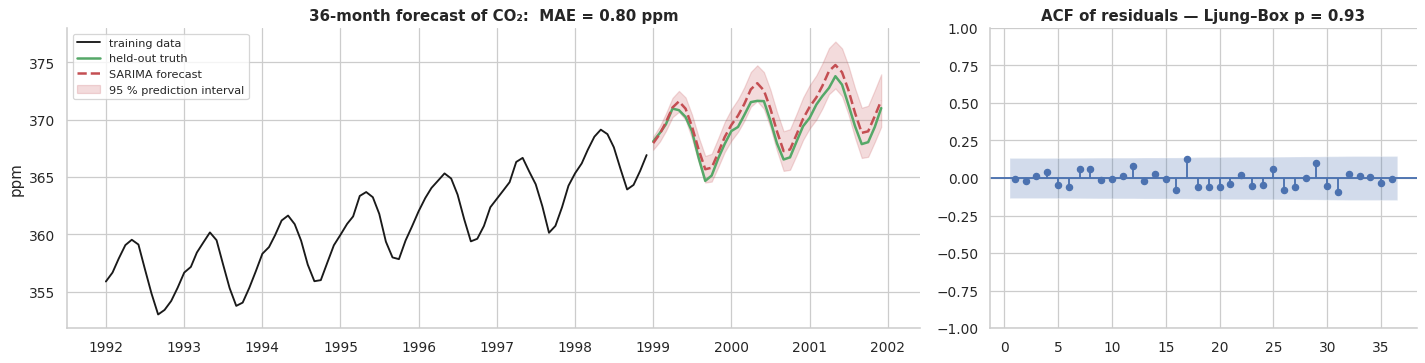

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3746      0.058     -6.498      0.000      -0.488      -0.262
ma.S.L12      -0.9975      2.665     -0.374      0.708      -6.220       4.225
sigma2         0.0805      0.211      0.381      0.703      -0.334       0.495


In [9]:
train, test = co2.iloc[:-36], co2.iloc[-36:]
res = SARIMAX(train, order=(0, 1, 1), seasonal_order=(0, 1, 1, 12)).fit(disp=False)
fc = res.get_forecast(36).summary_frame(alpha=.05)
lb = sm.stats.acorr_ljungbox(res.resid.iloc[13:], lags=[24]).lb_pvalue.iloc[0]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(16, 4.2), gridspec_kw={"width_ratios": [2, 1]})
a1.plot(train.loc["1992":], color="k", label="training data"); a1.plot(test, color=C[2], lw=2, label="held-out truth")
a1.plot(fc["mean"], color=C[3], lw=2, ls="--", label="SARIMA forecast"); a1.fill_between(fc.index, fc.mean_ci_lower, fc.mean_ci_upper, color=C[3], alpha=.2, label="95 % prediction interval")
a1.set(title=f"36-month forecast of CO₂:  MAE = {np.abs(test - fc['mean']).mean():.2f} ppm", ylabel="ppm"); a1.legend(fontsize=9)
plot_acf(res.resid.iloc[13:], lags=36, ax=a2, color=C[0], zero=False); a2.set_title(f"ACF of residuals — Ljung–Box p = {lb:.2f}")
plt.tight_layout(); plt.show()
print(res.summary().tables[1])

**Reading the figure.** The forecast tracks the hidden three years closely, and the truth stays inside the prediction interval, which **widens with the horizon** — uncertainty accumulates. The residual ACF shows no systematic structure and the Ljung–Box test does not reject "white noise": the model has extracted the predictable part of the series. (A very regular physical process such as this is the best case; business series are noisier, and their structure changes.) One technical remark on the coefficient table: the seasonal MA coefficient is estimated at the boundary (≈ −1), which signals an almost perfectly *stable* seasonal pattern; in that situation its reported standard error is unreliable and should be ignored.

---
## 8. Evaluating forecasts honestly

1. **Respect time.** Never shuffle: train on the past, test on the future. Random $k$-fold CV (Module 10) leaks future information.
2. **Always compare with naive benchmarks** — they are surprisingly hard to beat: the *naive* forecast (last value), the **seasonal naive** forecast (value of the same season one period ago), the *drift* forecast.
3. **Error measures:** MAE (robust, in original units), RMSE (punishes large errors), MAPE (percent; undefined at zero and biased towards under-forecasts), **MASE** (MAE divided by the in-sample MAE of the seasonal naive forecast; < 1 means "better than naive").
4. **Rolling-origin evaluation** ("time-series cross-validation"): move the forecast origin forward step by step, refit, forecast, and average the errors **per horizon**. One train/test split is a single, noisy draw.

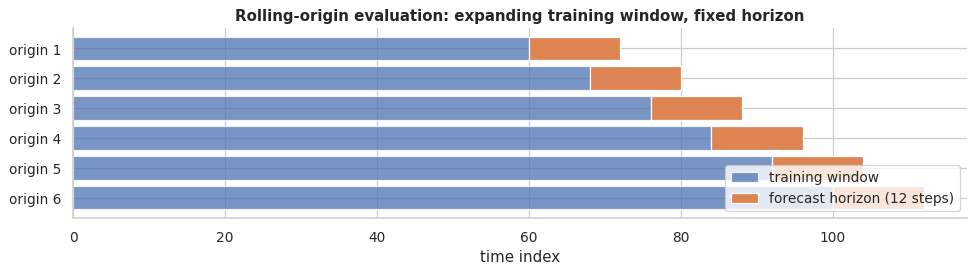

In [10]:
origins = list(range(60, 108, 8)); fig, ax = plt.subplots(figsize=(11, 3.2))
for row, o in enumerate(origins):
    ax.barh(row, o, color=C[0], alpha=.75, label="training window" if row == 0 else None); ax.barh(row, 12, left=o, color=C[1], label="forecast horizon (12 steps)" if row == 0 else None)
ax.set(yticks=range(len(origins)), yticklabels=[f"origin {r + 1}" for r in range(len(origins))], xlabel="time index", title="Rolling-origin evaluation: expanding training window, fixed horizon"); ax.invert_yaxis(); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

---
## 9. Exercises — real-world use cases
Each exercise is self-contained. Run the data cell, then work in the empty cell below it.

### ✍️ Exercise 13.1 — *Smoothing*: What is the real trend in daily orders? (E-commerce operations)

An online shop's daily order counts show a strong weekly rhythm. Operations wants to know the underlying growth, the typical weekday pattern, and whether anything unusual happened.

**Tasks**
1. Plot the series with a centred 7-day moving average and an EWMA ($\alpha=0.1$). Why 7 days?
2. Estimate the **weekday pattern**: average ratio of orders to the 7-day moving average, by weekday.
3. Remove the weekday pattern (orders / weekday factor), estimate a **robust** baseline with a centred 29-day rolling *median*, and flag days whose ratio to that baseline deviates from 1 by more than 4 robust SDs.
4. Estimate the average growth in orders per month from the baseline.

In [11]:
g = np.random.default_rng(1301)
days = pd.date_range("2025-01-01", periods=240, freq="D")
base = (400 + .9 * np.arange(240)) * np.array([1.0, .95, .97, 1.02, 1.15, 1.35, 1.25])[days.dayofweek]
base[150:154] *= 1.8                                                       # something happened here …
orders = pd.Series(g.poisson(base), index=days, name="orders")
orders.head(8)

2025-01-01    368
2025-01-02    382
2025-01-03    486
2025-01-04    530
2025-01-05    491
2025-01-06    419
2025-01-07    397
2025-01-08    378
Freq: D, Name: orders, dtype: int64

In [12]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/13_time_series_solutions.ipynb`.

### ✍️ Exercise 13.2 — *Decomposition*: Seasonally adjusting overnight stays (Tourism board)

A regional tourism board has ten years of monthly overnight stays (in thousands). The press office regularly compares "this month vs. last month", producing alarming headlines every autumn.

**Tasks**
1. Plot the series. Is the seasonality additive or multiplicative? Decide on a transformation.
2. Run an STL decomposition on the (transformed) series.
3. Convert the seasonal component into **seasonal factors** per calendar month (in %). Which months are peak and trough?
4. Compute the seasonally adjusted series and the average annual growth rate of the trend.
5. The latest November value is 20 % below October. What should the headline be?

In [13]:
g = np.random.default_rng(1302)
idx = pd.date_range("2015-01-01", periods=120, freq="MS"); t = np.arange(120)
season = 1 + .42 * np.cos(2 * np.pi * (idx.month - 8) / 12) + .15 * np.cos(4 * np.pi * (idx.month - 2) / 12)     # summer peak + small winter-sports bump
stays = pd.Series(80 * 1.04 ** (t / 12) * season * g.lognormal(0, .035, 120), index=idx, name="overnight_stays_k").round(1)
stays.tail(3)

2024-10-01    128.0
2024-11-01    102.3
2024-12-01     83.5
Freq: MS, Name: overnight_stays_k, dtype: float64

In [14]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/13_time_series_solutions.ipynb`.

### ✍️ Exercise 13.3 — *Stationarity & spurious regression*: Do these two share prices move together? (Finance)

An analyst shows you three years of daily prices of two companies from unrelated industries and a regression with $R^2\approx0.65$ and a t-statistic beyond 30: "clearly these stocks are linked — we can hedge one with the other."

**Tasks**
1. Regress price A on price B. Report $R^2$, the t-statistic and the **Durbin–Watson** statistic of the residuals.
2. Run ADF tests on both price series and on their daily log-returns.
3. Regress the returns of A on the returns of B. What remains of the relationship?
4. Explain to the analyst what went wrong.

In [15]:
g = np.random.default_rng(1311)
n = 750; dates = pd.bdate_range("2023-01-02", periods=n)
prices = pd.DataFrame({"A": 100 * np.exp(np.cumsum(g.normal(.0004, .012, n))), "B": 50 * np.exp(np.cumsum(g.normal(.0003, .015, n)))}, index=dates).round(2)
prices.tail(3)

,A,B
2025-11-12,185.75,83.75
2025-11-13,186.87,85.95
2025-11-14,188.79,89.52


In [16]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/13_time_series_solutions.ipynb`.

### ✍️ Exercise 13.4 — *SARIMA forecasting against a benchmark*: Next year's electricity demand (Energy utility)

A utility has 13 years of monthly electricity demand (GWh). Planning needs a 24-month forecast with uncertainty bands.

**Tasks**
1. Hold out the last 24 months. Plot the training series; describe trend and seasonality.
2. Fit two candidates on the training data — SARIMA(0,1,1)(0,1,1)₁₂ and SARIMA(1,0,0)(0,1,1)₁₂ with drift (`trend="c"`) — and compare their AIC. Check the better model's residuals (Ljung–Box).
3. Forecast 24 months. Compare MAE and MAPE on the hold-out with the **seasonal naive** benchmark. Compute the MASE.
4. How many of the 24 true values fall inside the 95 % prediction interval?

In [17]:
g = np.random.default_rng(1304)
idx = pd.date_range("2012-01-01", periods=156, freq="MS"); t = np.arange(156)
e = np.zeros(156)
for i in range(1, 156): e[i] = .6 * e[i - 1] + g.normal(0, 18)
demand = pd.Series(1500 + 1.8 * t + 120 * np.cos(2 * np.pi * (idx.month - 1) / 12) + 35 * np.cos(4 * np.pi * (idx.month - 7) / 12) + e, index=idx, name="demand_gwh").round(0)
demand.tail(3)

2024-10-01    1782.0
2024-11-01    1868.0
2024-12-01    1931.0
Freq: MS, Name: demand_gwh, dtype: float64

In [18]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/13_time_series_solutions.ipynb`.

### ✍️ Exercise 13.5 — *Rolling-origin evaluation*: Is Holt–Winters worth it? (Retail demand planning)

A retailer forecasts monthly sales 12 months ahead. Candidates: **Holt–Winters** exponential smoothing (additive trend, multiplicative seasonality) and the **seasonal naive** method. One train/test split could be luck — evaluate with a rolling origin.

**Tasks**
1. Starting with 72 months of training data, move the origin forward in steps of 3 months as long as 12 future months remain. At each origin fit Holt–Winters, forecast 12 months, and store the absolute percentage errors of both methods **by horizon**.
2. Plot the MAPE against the forecast horizon for both methods.
3. Report the overall MAPE. By how much does Holt–Winters beat the benchmark — and does accuracy decay with the horizon?

In [19]:
g = np.random.default_rng(1305)
idx = pd.date_range("2014-01-01", periods=132, freq="MS"); t = np.arange(132)
fac = np.array([.82, .80, .92, .97, 1.0, .98, .95, .93, 1.0, 1.05, 1.22, 1.55])                # Christmas business
sales = pd.Series(200 * 1.05 ** (t / 12) * fac[idx.month - 1] * g.lognormal(0, .05, 132), index=idx, name="sales_k").round(1)
sales.tail(3)

2024-10-01    366.5
2024-11-01    442.7
2024-12-01    535.8
Freq: MS, Name: sales_k, dtype: float64

In [20]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/13_time_series_solutions.ipynb`.

---
## 10. 🔑 Key takeaways

* Time-series observations are **dependent**; the ACF measures that dependence. Ignoring it makes every standard error too small.
* Think in components: **trend, seasonality, remainder**; multiplicative patterns become additive after a **log**. STL decomposes robustly; seasonally adjusted figures enable fair month-to-month comparisons.
* **Stationarity** is the prerequisite for modelling; **differencing** produces it. Independent random walks correlate "significantly" most of the time — check residual autocorrelation, analyse changes rather than levels.
* **ACF/PACF** identify AR and MA structure; **SARIMA** = differencing + AR + MA, at ordinary and seasonal lags. Residuals must be white noise.
* Judge forecasts **out of sample**, against **naive benchmarks**, by horizon (rolling origin), and always deliver **prediction intervals**.

### Cheat sheet
| Task | Code |
|---|---|
| resample / rolling / EWMA | `s.resample("MS").mean()`, `s.rolling(7, center=True).mean()`, `s.ewm(alpha=.1).mean()` |
| differences, lags, autocorrelation | `s.diff()`, `s.diff(12)`, `s.shift(1)`, `s.autocorr(12)` |
| ACF / PACF plots | `plot_acf(s, lags=36)`, `plot_pacf(s, lags=36)` |
| decomposition | `STL(s, period=12, robust=True).fit()` → `.trend`, `.seasonal`, `.resid` |
| unit-root test | `adfuller(s)[1]` (H₀: non-stationary) |
| SARIMA | `res = SARIMAX(s, order=(p, d, q), seasonal_order=(P, D, Q, 12)).fit(disp=False)` |
| forecast with intervals | `res.get_forecast(h).summary_frame(alpha=.05)` |
| residual check | `sm.stats.acorr_ljungbox(res.resid, lags=[24])`, `durbin_watson(resid)` |
| Holt–Winters | `ExponentialSmoothing(s, trend="add", seasonal="mul", seasonal_periods=12).fit().forecast(h)` |

---
## 🎓 You have completed the Statistics Deep Dive

From describing a single variable to forecasting the future: you now command the core toolkit of applied statistics. The best next step is to **use it on your own data** — and to keep three habits from this course: *plot first*, *quantify uncertainty*, and *ask how the data came to be* before believing any number.